# Internship/Job Scam Detection System 

In [29]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from numba import njit
!nvidia-smi

Sat Sep 19 18:52:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.97                 Driver Version: 580.97         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P0             10W /   55W |      13MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
# loading the training dataset
df_org = pd.read_csv("Internship_dataset.csv")   # 1000000 rows × 33 columns 

df_selected = df_org[["internship_title","employment_type","work_mode","industry","location","company_name","company_size","company_age","linkedin_presence","website_available","verification_status","stipend","registration_fee","job_description_length","vague_description_score","urgency_score","keyword_spam_score","suspicious_email_domain","social_media_presence","is_fake_posting"]]

df_selected.sample(5)   # 1000000 x 20 

,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,website_available,verification_status,stipend,registration_fee,job_description_length,vague_description_score,urgency_score,keyword_spam_score,suspicious_email_domain,social_media_presence,is_fake_posting
991089,Cloud Engineer,Internship,Hybrid,Marketing,Bangalore,"Johnson, Gomez and Vargas",Startup,31.0,1,1,1,68464.0,0,1898,44,27,48,0,1,0
94575,UI/UX Designer,Contract,Remote,EdTech,Singapore,"Thompson, Anderson and Martinez",Startup,28.0,0,1,1,7691.0,0,2362,58,0,15,0,1,0
169123,Backend Developer,Part-Time,Remote,Healthcare,Singapore,Glenn LLC,Enterprise,38.0,1,1,0,30235.0,0,1942,7,46,13,1,1,0
41178,Marketing Intern,Full-Time,Hybrid,Software,Toronto,Lewis-Ellison,Startup,29.0,1,0,1,33085.0,0,1155,7,44,0,0,1,0
708311,Cloud Engineer,Internship,Onsite,E-Commerce,San Francisco,Snyder LLC,Startup,36.0,1,1,1,50171.0,0,1633,32,49,18,0,1,0


In [27]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   internship_title         1000000 non-null  object 
 1   employment_type          1000000 non-null  object 
 2   work_mode                1000000 non-null  object 
 3   industry                 1000000 non-null  object 
 4   location                 1000000 non-null  object 
 5   company_name             1000000 non-null  object 
 6   company_size             1000000 non-null  object 
 7   company_age              990000 non-null   float64
 8   linkedin_presence        1000000 non-null  int64  
 9   website_available        1000000 non-null  int64  
 10  verification_status      1000000 non-null  int64  
 11  stipend                  990000 non-null   float64
 12  registration_fee         1000000 non-null  int64  
 13  job_description_length   1000000 non-null  

<Axes: title={'center': 'Correlation Plot'}>

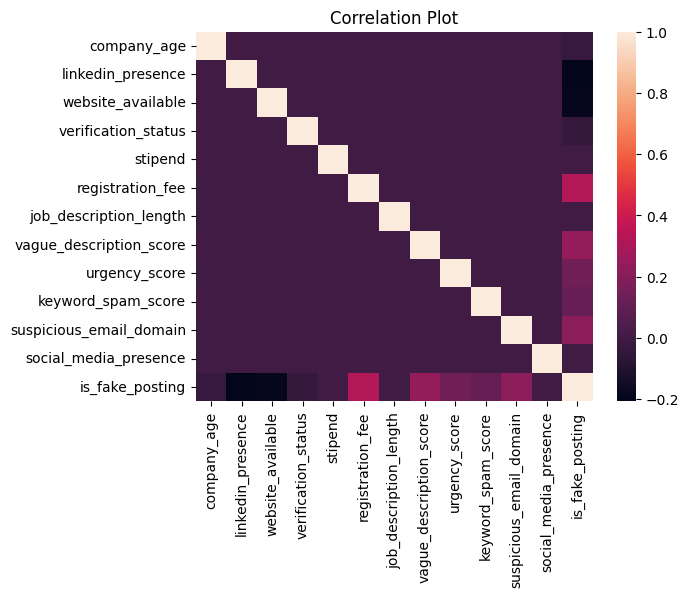

In [28]:
plt.title("Correlation Plot")
sns.heatmap(df_selected.corr(numeric_only=True))          

In [ ]:

# train_df.drop(['job_id','department','salary_range'],axis = 1, inplace = True)

# # handling Null values in text columns with space

# col = ['title','location','company_profile','description','requirements','benefits']
# train_df[col] = train_df[col].fillna(" ")

# # train_df.isnull().describe()

# train_df = train_df.fillna("unknown",axis = 1)
# train_df['fraudulent'] = train_df['fraudulent'].astype(int)

# train_df.drop("text",axis = 1, inplace = )
# Now the data is clean and having 0 null values

In [ ]:
# merging all text in text column
# train_df["text"] = (
#     train_df["title"].fillna('') + " " +
#     train_df["location"].fillna('') + " " +
#     train_df["company_profile"].fillna('') + " " +
#     train_df["description"].fillna('') + " " +
#     train_df["requirements"].fillna('') + " " +
#     train_df["benefits"].fillna('')
# )
# train_df['text'].nunique()  to check uniqueness of text   &  train_df['text'].iloc[0]


In [ ]:
# using TF_IDF vectorize for text to numbers
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
X = vectorizer.fit_transform(train_df['text'])
print("TF-IDF matrix shape:", X.shape)


In [ ]:
# splitting data into test and train and training the model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# target variable
y = train_df['fraudulent']  

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



In [ ]:
# evaluation
y_pred = model.predict(X_test)
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
# evaluation train
y_pred = model.predict(X_train)
print("F1 Score:", f1_score(y_train, y_pred))
print(classification_report(y_train, y_pred))


In [ ]:
# fitting the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)


In [ ]:
# # saving the model
# import joblib
# joblib.dump(model, 'fraud_job_model.pkl')
# joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')